In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sns
import os

# df_Enamine_DR_growthCurves

In [2]:
df_Enamine_DR_growthCurves=pd.read_csv('/home/ethan2/GrowthNet/data/raw/Enamine_DR_growthcurves.csv')

df_Enamine_DR_growthCurves=df_Enamine_DR_growthCurves.rename(columns={"Plate":"Plate_ID"})
df_Enamine_DR_growthCurves['Control_Label'] = 0

df_Enamine_DR_growthCurves=df_Enamine_DR_growthCurves.drop(columns=['MIC'])


timepoints = sorted([c for c in df_Enamine_DR_growthCurves.columns if c.startswith('t_')],
                    key=lambda s: float(s.split('_')[1]))

df_Enamine_DR_growthCurves=df_Enamine_DR_growthCurves.melt(
        id_vars=['Well', 'Plate_ID', 'Concentration',
               'Compound','Replicate','Control_Label', 'Smiles'],
        value_vars=timepoints,
        var_name='Timepoint',
        value_name='OD'
    )


df_Enamine_DR_growthCurves['Timepoint'] = df_Enamine_DR_growthCurves['Timepoint'] \
                   .str.replace('t_', '', regex=False) \
                   .astype(float)

DR_compounds=set(df_Enamine_DR_growthCurves['Compound'])


df_cntrl=pd.read_csv('/home/ethan2/GrowthNet/data/raw/Control_growthcurves.csv')

df_cntrl['Control_Label'] = df_cntrl["Compound"].apply(
    lambda x: -1 if x == 'DMSO' else 1
)

timepoints = sorted([c for c in df_cntrl.columns if c.startswith('t_')],
                    key=lambda s: float(s.split('_')[1]))

df_cntrl=df_cntrl.melt(
        id_vars=['Well', 'Concentration',
               'Compound','Replicate','Control_Label', 'Smiles'],
        value_vars=timepoints,
        var_name='Timepoint',
        value_name='OD'
    )
df_cntrl['Timepoint'] = df_cntrl['Timepoint'] \
                   .str.replace('t_', '', regex=False) \
                   .astype(float)
                   
df_cntrl['Plate_ID'] = 'NA'



# df_Enamine_t6_t12_wells/controls

In [3]:
df_Enamine_t6_t12_wells=pd.read_csv('/home/ethan2/GrowthNet/data/raw/Enamine_t6_t12_wells.csv')
df_Enamine_t6_t12_controls=pd.read_csv('/home/ethan2/GrowthNet/data/raw/Enamine_t6_t12_ctrls.csv')
df_Enamine_t6_t12_controls = df_Enamine_t6_t12_controls.drop(columns=['Unnamed: 0'], errors='ignore')

df_Enamine_t6_t12_wells=df_Enamine_t6_t12_wells.rename(columns={'t_6': 't_6.24','t_12':'t_12.48'})
df_Enamine_t6_t12_controls=df_Enamine_t6_t12_controls.rename(columns={'t_6': 't_6.24','t_12':'t_12.48'})


df_Enamine_t6_t12_wells['Concentration'] = 50
df_Enamine_t6_t12_controls['Concentration'] = 50

df_Enamine_t6_t12_wells['Control_Label'] = 0


df_Enamine_t6_t12_controls['Control_Label'] = df_Enamine_t6_t12_controls["Compound"].apply(
    lambda x: 1 if x == 'Ciprofloxacin' else -1
)

Ericks_actives=set(df_Enamine_t6_t12_wells[df_Enamine_t6_t12_wells['Activity'] =='Active']['Compound'])

df_Enamine_t6_t12_wells=df_Enamine_t6_t12_wells.drop(columns=['Activity'])


df_Enamine=pd.concat([df_Enamine_t6_t12_controls,df_Enamine_t6_t12_wells], ignore_index=True)

timepoints = sorted([c for c in df_Enamine.columns if c.startswith('t_')],
                    key=lambda s: float(s.split('_')[1]))


df_Enamine = df_Enamine.melt(
        id_vars=['Well', 'Plate_ID', 'Concentration',
               'Compound','Replicate','Control_Label', 'Smiles'],
        value_vars=timepoints,
        var_name='Timepoint',
        value_name='OD'
    )

df_Enamine['Timepoint'] = df_Enamine['Timepoint'] \
                   .str.replace('t_', '', regex=False) \
                   .astype(float)


# Functions

In [4]:
def correct_well_batch_effect_time_conc(df_long):
    """
    Multiplicative well-level batch correction.

    For each (Well, Timepoint, Concentration), compute the median OD over rows
    currently labelled inactive (`is_Active == 0`) and rescale every row at that
    spot by `global_median(T, C) / well_median(T, C)`. Skips Timepoint == 0.

    Caller must populate `is_Active` first (the iterator does this).
    """
    inactive = df_long[df_long['is_Active'] == 0]

    well_medians = (
        inactive
        .groupby(['Well', 'Timepoint', 'Concentration'])['OD']
        .median()
        .reset_index(name='well_meds')
    )

    global_medians = (
        inactive
        .groupby(['Timepoint', 'Concentration'])['OD']
        .median()
        .reset_index(name='global_meds')
    )

    df = df_long.merge(well_medians, on=['Well', 'Timepoint', 'Concentration'], how='left')
    df = df.merge(global_medians, on=['Timepoint', 'Concentration'], how='left')

    mask = df['Timepoint'] != 0
    df.loc[mask, 'OD'] = (
        df.loc[mask, 'OD']
        / df.loc[mask, 'well_meds']
        * df.loc[mask, 'global_meds']
    )

    df = df.drop(columns=['well_meds', 'global_meds'])
    return df, global_medians, well_medians


In [5]:
def correct_plate_batch_effect_dmso(df: pd.DataFrame) -> pd.DataFrame:
    """
    Plate-level batch correction using DMSO wells as the reference.

    Divides each OD by its plate's DMSO median and multiplies by the global DMSO
    median at the same (Timepoint, Concentration). Preserves the OD scale — since
    the global DMSO median grows with time, corrected OD values also grow with time —
    while removing plate-to-plate offset. Skips Timepoint == 0.

    No iteration needed: DMSO labels are fixed by design, so there is no circularity
    between labels and the correction factor.
    """
    dmso = df[df['Control_Label'] == -1]

    plate_meds = (
        dmso
        .groupby(['Plate_ID', 'Timepoint', 'Concentration'])['OD']
        .median()
        .reset_index(name='plate_dmso_med')
    )

    global_meds = (
        dmso
        .groupby(['Timepoint', 'Concentration'])['OD']
        .median()
        .reset_index(name='global_dmso_med')
    )

    df_norm = df.merge(plate_meds, on=['Plate_ID', 'Timepoint', 'Concentration'], how='left')
    df_norm = df_norm.merge(global_meds, on=['Timepoint', 'Concentration'], how='left')

    denom = df_norm['plate_dmso_med'].to_numpy()
    numer = df_norm['global_dmso_med'].to_numpy()

    mask = (
        (df_norm['Timepoint'] != 0)
        & (denom > 0)
        & np.isfinite(denom)
        & np.isfinite(numer)
    )
    df_norm.loc[mask, 'OD'] = df_norm.loc[mask, 'OD'] * numer[mask] / denom[mask]

    df_norm = df_norm.drop(columns=['plate_dmso_med', 'global_dmso_med'])
    return df_norm

In [6]:
def plot_hist_od_distributions_long_neg_ctrl_threshold(
    title,
    correct_uncorrect,                                                                    
    dataset,
    df_long,                                                                              
    bins,                                                                                 
    concentration,
    max_density,                                                                          
    max_x,                                                                                
    plot_pos_ctrls: bool = True, 
    save_path: bool = False,                                                              
):                                                                                        
    """
    Plot overlaid OD histograms by Control_Label at each timepoint.                       
    Vertical lines show median ± n*MAD calculated from NEGATIVE CONTROLS (Control_Label ==
-1).                                                                                     
    """                                                                                   
    def _bins_for(label):                                                                 
        if not isinstance(bins, dict):                                                    
            return bins
        return bins.get(label, 30)                                                        
                
    base_labels = [-1, 0, 1]                                                              
    labels      = base_labels if plot_pos_ctrls else [-1, 0]
    colors      = {-1: '#1f77b4', 0: '#ff7f0e', 1: '#2ca02c'}                             
    label_names = {-1: "Negative Control", 0: "Test Compound", 1: "Positive Control"}     
                                                                                        
    df_sub = df_long[df_long['Concentration'] == concentration]                           
    timepoints = np.sort(df_sub['Timepoint'].unique())
                                                                                        
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))                                      
    axes = axes.flatten()
                                                                                        
    for i, tp in enumerate(timepoints):                                                   
        ax     = axes[i]
        sub_tp = df_sub[df_sub['Timepoint'] == tp]                                        
                
        for lab in labels:
            grp = sub_tp[sub_tp['Control_Label'] == lab]
            ax.hist(                                                                      
                grp['OD'],
                bins=_bins_for(lab),                                                      
                alpha=0.30,
                density=True,
                label=label_names[lab],
                color=colors[lab],
                histtype='stepfilled',                                                    
                edgecolor='black',
                linewidth=0.7                                                             
            )   

        # Compute median and MAD on NEGATIVE CONTROLS (Control_Label == -1)
        neg_ctrl_grp = sub_tp[sub_tp['Control_Label'] == -1]
        med      = neg_ctrl_grp['OD'].median()                                            
        mad      = 1.4826 * np.median(np.abs(neg_ctrl_grp['OD'].dropna() - med))
                                                                                        
        ax.text(
            0.98, 0.95,                                                                   
            f"MAD = {mad:.5f}",
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.25", fc="w", ec="0.7", alpha=0.7)
        )                                                                                 

        if i == 0:                                                                        
            ax.axvline(med,         color='black',  linestyle='--', linewidth=1.5,
label='Median')                                                                           
            ax.axvline(med - mad,   color='red',    linestyle=':',  linewidth=1.5,
label='-1 MAD')                                                                           
            ax.axvline(med - 2*mad, color='orange', linestyle=':',  linewidth=1.5,
label='-2 MAD')                                                                           
            ax.axvline(med - 3*mad, color='green',  linestyle=':',  linewidth=1.5,
label='-3 MAD')                                                                           
            ax.axvline(med - 4*mad, color='blue',   linestyle=':',  linewidth=1.5,
label='-4 MAD')                                                                           
        else:   
            for k, col in enumerate(['black', 'red', 'orange', 'green', 'blue']):
                ax.axvline(                                                               
                    med - k*mad,
                    color=col,                                                            
                    linestyle='--' if k == 0 else ':',
                    linewidth=1.5
                )                                                                         

        ax.set_title(str(tp))                                                             
        ax.set_xlabel('OD')
        ax.set_ylabel('Density')
        ax.set_ylim(0, max_density)
        ax.set_xlim(0, max_x)
        ax.grid(True, linestyle='--', alpha=0.5)                                          

    for j in range(len(timepoints), len(axes)):                                           
        fig.delaxes(axes[j])

    handles, labels_ = axes[0].get_legend_handles_labels()                                
    fig.legend(handles, labels_, loc='lower right', title='Control_Label')
                                                                                        
    fig.suptitle(f'OD Distributions at {concentration} µM with {title}', fontsize=16)     
    plt.tight_layout(rect=[0, 0, 0.95, 0.95])
                                                                                        
    if save_path:
        plt.savefig(
            f'/Users/ethankreuzer/Desktop/MILA/GrowthCurvePlots/well_medians/'
                                                                                        
f'{dataset}/{correct_uncorrect}_OD_dist/Well_OD_distribution_conc_{concentration}.png'
        )                                                                                 
    else:       
        plt.show()


In [7]:

def plot_activity_ratio_heatmap(df):
    # 1) Determine the exact list of concentrations and timepoints, in sorted order
    conc_values = sorted(df['Concentration'].unique())
    time_values = sorted(df['Timepoint'].unique())

    # 2) Build the “total” and “active” count tables, then reindex so they share the same shape/order
    total_counts = (
        df
        .groupby(['Concentration', 'Timepoint'])
        .size()
        .unstack(fill_value=0)
        .reindex(index=conc_values, columns=time_values, fill_value=0)
    )

    active_counts = (
        df[df['is_Active'] == 1]
        .groupby(['Concentration', 'Timepoint'])
        .size()
        .unstack(fill_value=0)
        .reindex(index=conc_values, columns=time_values, fill_value=0)
        .astype(int)
    )

    # 3) Compute fraction = active / total (avoiding division by zero)
    fraction = active_counts.divide(total_counts.replace(0, 1))
    fraction = fraction.fillna(0)

    # 4) Prepare annotation strings “active/total”
    annot = active_counts.astype(str) + "/" + total_counts.astype(str)

    # 5) Plot
    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(
        fraction,
        annot=annot,
        fmt="",
        cmap="viridis",
        cbar_kws={'label': 'Fraction Active'}
    )

    # 6) Set the x‐ and y‐tick labels to the string versions of the numeric values
    ax.set_xticklabels([str(x) for x in time_values])
    ax.set_yticklabels([str(x) for x in conc_values], rotation=0)

    ax.set_xlabel('Timepoint')
    ax.set_ylabel('Concentration')
    ax.set_title('Active / Total Compounds (Test set)')

    plt.tight_layout()
    plt.show()


In [8]:
def label_inactives_actives(df_long: pd.DataFrame, mad_multiplier) -> pd.DataFrame:
    
    def _compute_thresh(group):
        # isolate negative controls
        dmso = group.loc[group['Control_Label'] == -1, 'OD']
        if len(dmso) > 0:
            med = dmso.median()
            mad = 1.4826 * np.median(np.abs(dmso - med))
        else:
            med = group['OD'].median()
            mad = 1.4826 * np.median(np.abs(group['OD'] - med))
        return med - mad_multiplier * mad

   
    thresholds = (
        df_long
        .groupby(['Plate_ID', 'Concentration', 'Timepoint'])
        .apply(_compute_thresh)
        .reset_index(name='threshold')
    )

    
    combined = (
        df_long
        .drop(columns=['threshold'], errors='ignore')  # in case it existed
        .merge(thresholds, on=['Plate_ID', 'Concentration', 'Timepoint'], how='left')
    )

    # 4) Label active/inactive
    combined['is_Active'] = (combined['OD'] < combined['threshold']).astype(int)

    combined.drop(columns=['threshold'], inplace=True)  

    return combined

In [9]:
def iterate_label_and_well_correct(
    df_base: pd.DataFrame,
    mad_multiplier: float = 4,
    max_iters: int = 10,
    tol: float = 0.01,
    plot_each_iter: bool = False,
):
    """
    Iteratively refine active/inactive labels and the well-correction factor.

    Each iteration:
      1. Labels test compounds using median - mad_multiplier*MAD on DMSO per
         (Plate_ID, Concentration, Timepoint).
      2. Recomputes well-correction factors from rows currently labeled is_Active==0.
      3. Applies those factors to df_base's OD (not compounded across iterations).
      4. Relabels on the freshly corrected OD.

    Stops when the fraction of label flips among test compounds (Control_Label==0)
    falls below `tol`, or after `max_iters` rounds.

    Returns (df_final, flip_history).
    """
    df_base = df_base.reset_index(drop=True)
    df_cur = label_inactives_actives(df_base, mad_multiplier=mad_multiplier)

    if plot_each_iter:
        print("--- Initial labels (before any well correction) ---")
        plot_activity_ratio_heatmap(df_cur[df_cur['Control_Label'] == 0])

    flip_history = []
    for it in range(1, max_iters + 1):
        df_for_correct = df_base.copy()
        df_for_correct['is_Active'] = df_cur['is_Active'].to_numpy()

        df_corrected, _, _ = correct_well_batch_effect_time_conc(df_for_correct)
        df_new = label_inactives_actives(df_corrected, mad_multiplier=mad_multiplier)

        test_mask = df_new['Control_Label'] == 0
        n_test = int(test_mask.sum())
        flips = int(
            (df_cur.loc[test_mask, 'is_Active'].to_numpy()
             != df_new.loc[test_mask, 'is_Active'].to_numpy()).sum()
        )
        frac = flips / max(n_test, 1)
        flip_history.append({'iter': it, 'flips': flips, 'frac': frac})
        print(f"iter {it}: flips={flips}  ({frac:.4%} of {n_test} test rows)")

        if plot_each_iter:
            print(f"--- Active labels after iter {it} ---")
            plot_activity_ratio_heatmap(df_new[df_new['Control_Label'] == 0])

        df_cur = df_new
        if frac < tol:
            print(f"Converged at iter {it} (flip fraction < {tol:.0%}).")
            return df_cur, flip_history

    print(f"Stopped at max_iters={max_iters} without hitting the tolerance.")
    return df_cur, flip_history


In [10]:
def plot_hist_od_distributions_long(
    title,
    correct_uncorrect,
    dataset,
    df_long,
    bins,                       
    concentration,
    max_density,
    max_x,
    plot_pos_ctrls: bool = True, 
    save_path: bool = False,
):
    """
    Plot overlaid OD histograms by Control_Label at each timepoint,
    allowing a different `bins` specification for each label.
    """
    # ── helper to fetch per-label bins ───────────────────────────────────────────
    def _bins_for(label):
        if not isinstance(bins, dict):
            return bins
        return bins.get(label, 30)

    base_labels = [-1, 0, 1]
    labels      = base_labels if plot_pos_ctrls else [-1, 0]
    colors      = {-1: '#1f77b4', 0: '#ff7f0e', 1: '#2ca02c'}
    label_names = {-1: "Negative Control", 0: "Test Compound", 1: "Positive Control"}

    # 1) Extract only rows at the requested concentration
    df_sub = df_long[df_long['Concentration'] == concentration]

    # 2) Compute the ordered list of numerically‐sorted timepoints
    #    (so we use the same order for plotting and for knowing how many axes to keep)
    timepoints = np.sort(df_sub['Timepoint'].unique())

    # 3) Create a 2×4 grid (eight possible axes)
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    for i, tp in enumerate(timepoints):
        ax     = axes[i]
        sub_tp = df_sub[df_sub['Timepoint'] == tp]

        # Plot one histogram per Control_Label
        for lab in labels:
            grp = sub_tp[sub_tp['Control_Label'] == lab]
            ax.hist(
                grp['OD'],
                bins=_bins_for(lab),
                alpha=0.30,
                density=True,
                label=label_names[lab],
                color=colors[lab],
                histtype='stepfilled',
                edgecolor='black',
                linewidth=0.7
            )

        # Compute median and MAD on test compounds (Control_Label == 0)
        test_grp = sub_tp[sub_tp['Control_Label'] == 0]
        med      = test_grp['OD'].median()
        mad      = 1.4826 * np.median(np.abs(test_grp['OD'].dropna() - med))

        ax.text(
            0.98, 0.95,
            f"MAD = {mad:.5f}",
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.25", fc="w", ec="0.7", alpha=0.7)
        )

        # Plot vertical reference lines only on the first subplot (i == 0)
        if i == 0:
            ax.axvline(med,         color='black',  linestyle='--', linewidth=1.5, label='Median')
            ax.axvline(med - mad,   color='red',    linestyle=':',  linewidth=1.5, label='-1 MAD')
            ax.axvline(med - 2*mad, color='orange', linestyle=':',  linewidth=1.5, label='-2 MAD')
            ax.axvline(med - 3*mad, color='green',  linestyle=':',  linewidth=1.5, label='-3 MAD')
            ax.axvline(med - 4*mad, color='blue',   linestyle=':',  linewidth=1.5, label='-4 MAD')
        else:
            for k, col in enumerate(['black', 'red', 'orange', 'green', 'blue']):
                ax.axvline(
                    med - k*mad,
                    color=col,
                    linestyle='--' if k == 0 else ':',
                    linewidth=1.5
                )

        ax.set_title(str(tp))
        ax.set_xlabel('OD')
        ax.set_ylabel('Density')
        ax.set_ylim(0, max_density)
        ax.set_xlim(0, max_x)
        ax.grid(True, linestyle='--', alpha=0.5)

    # 4) Delete any leftover unused axes
    #    (for instance, if there are only 7 timepoints, we want to remove axes[7])
    for j in range(len(timepoints), len(axes)):
        fig.delaxes(axes[j])

    # 5) Reconstruct a single legend from the very first subplot
    handles, labels_ = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc='lower right', title='Control_Label')

    fig.suptitle(f'OD Distributions at {concentration} µM with {title}', fontsize=16)
    plt.tight_layout(rect=[0, 0, 0.95, 0.95])

    if save_path:
        plt.savefig(
            f'/Users/ethankreuzer/Desktop/MILA/GrowthCurvePlots/well_medians/'
            f'{dataset}/{correct_uncorrect}_OD_dist/Well_OD_distribution_conc_{concentration}.png'
        )
    else:
        plt.show()


In [11]:
def plot_od_with_dmso_threshold(
    df_test: pd.DataFrame,
    df_dmso: pd.DataFrame,
    title: str,
    concentration: float,
    mad_multiplier: int = 4,
    bins: int = 25,
    max_density: float = 8,
    max_x: float = 1.2,
    save_path: bool = False,
):
    """
    Plot OD histograms at each timepoint for a given concentration.
    Each subplot overlays:
      - Orange: test compound OD distribution
      - Blue:   DMSO OD (all replicates, not averaged)
      - Vertical lines: DMSO median (black dashed) and median - 1..mad_multiplier * MAD

    DMSO is pooled across concentrations at each timepoint since DMSO OD is
    independent of the compound-concentration column it occupied.
    """
    dmso = df_dmso[df_dmso['Control_Label'] == -1]

    time_values = sorted(df_test[df_test['Concentration'] == concentration]['Timepoint'].unique())
    n_time = len(time_values)

    thresh_colors = ['black', 'red', 'orange', 'green', 'blue', 'purple']

    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    for j, tp in enumerate(time_values):
        ax = axes[j]

        test_sub = df_test[
            (df_test['Concentration'] == concentration) &
            (df_test['Timepoint'] == tp)
        ]['OD'].dropna()

        dmso_sub = dmso[dmso['Timepoint'] == tp]['OD'].dropna()

        ax.hist(test_sub, bins=bins, alpha=0.4, density=True,
                color='#ff7f0e', histtype='stepfilled',
                edgecolor='black', linewidth=0.5,
                label='Test compounds' if j == 0 else None)

        ax.hist(dmso_sub, bins=bins, alpha=0.5, density=True,
                color='#1f77b4', histtype='stepfilled',
                edgecolor='black', linewidth=0.5,
                label='DMSO' if j == 0 else None)

        if len(dmso_sub) > 1:
            med = dmso_sub.median()
            mad = 1.4826 * np.median(np.abs(dmso_sub - med))

            for k in range(mad_multiplier + 1):
                ax.axvline(
                    med - k * mad,
                    color=thresh_colors[k],
                    linestyle='--' if k == 0 else ':',
                    linewidth=1.5,
                    label=('DMSO median' if k == 0 else f'-{k} MAD') if j == 0 else None,
                )

            ax.text(0.97, 0.95, f'MAD={mad:.3f}',
                    transform=ax.transAxes, ha='right', va='top',
                    fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.25', fc='w', ec='0.7', alpha=0.7))

        ax.set_title(str(tp))
        ax.set_xlabel('OD')
        ax.set_ylabel('Density')
        ax.set_xlim(0, max_x)
        ax.set_ylim(0, max_density)
        ax.grid(True, linestyle='--', alpha=0.5)

    for j in range(n_time, len(axes)):
        fig.delaxes(axes[j])

    handles, labels_ = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc='lower right', fontsize=9, title='Legend')
    fig.suptitle(f'{title} — {concentration} µM', fontsize=14)
    plt.tight_layout(rect=[0, 0, 0.95, 0.95])

    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    else:
        plt.show()


# Enamine DR processing 

## Labeling strategy: k=2 seed → iterative well correction → k=3 DMSO CV-rescaled final

DR plates have **no on-plate DMSO**. Batch correction must use the test compounds
themselves as the inactive reference, which creates a chicken-and-egg problem:
the inactive reference depends on which compounds are labeled inactive.

**Seed labels (k=2):** The first pass uses the per-plate test-compound
median − 2·MAD as a conservative threshold. k=2 is intentionally loose:
the distribution is biased (depressed median, inflated MAD when many compounds
are genuinely active), so we only aim to exclude obvious actives to give the
plate/well correction a reasonable reference pool. These labels are *not* trusted
as final activity calls.

**Iterative well correction:** The same iteration used for t6_t12 is applied,
anchored to the k=2 seed. Each round refines the well factors on the growing
set of converged inactive labels.

**Final labels (k=3, DMSO CV-rescaled):** After well correction, the external
DMSO dataset is used to set the threshold via:

    threshold(T, C) = m_DR_inactive(T, C) × (1 − 3 × CV_DMSO(T))

where `CV_DMSO` is pooled across concentrations (DMSO OD doesn't depend on
concentration; pooling stabilizes the MAD estimate). The iteration
converges in ~3 rounds. See `scripts/dmso_threshold_methodology.md` for the
full derivation and diagnostics.

/tmp/ipykernel_1026848/3253228211.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_compute_thresh)
/tmp/ipykernel_1026848/3253228211.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_compute_thresh)


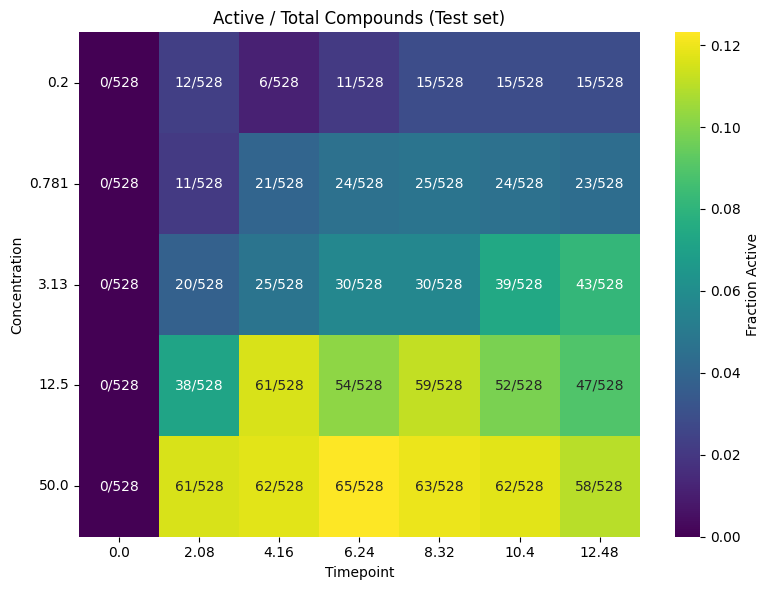

/tmp/ipykernel_1026848/3253228211.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_compute_thresh)
/tmp/ipykernel_1026848/3253228211.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_compute_thresh)


iter 1: flips=717  (3.8799% of 18480 test rows)
iter 2: flips=171  (0.9253% of 18480 test rows)


/tmp/ipykernel_1026848/3253228211.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_compute_thresh)
/tmp/ipykernel_1026848/3253228211.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_compute_thresh)


iter 3: flips=46  (0.2489% of 18480 test rows)
iter 4: flips=10  (0.0541% of 18480 test rows)
Converged at iter 4 (flip fraction < 0%).
Seed active fractions (k=2 internal-MAD, before DMSO CV rescaling):


/tmp/ipykernel_1026848/3253228211.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_compute_thresh)


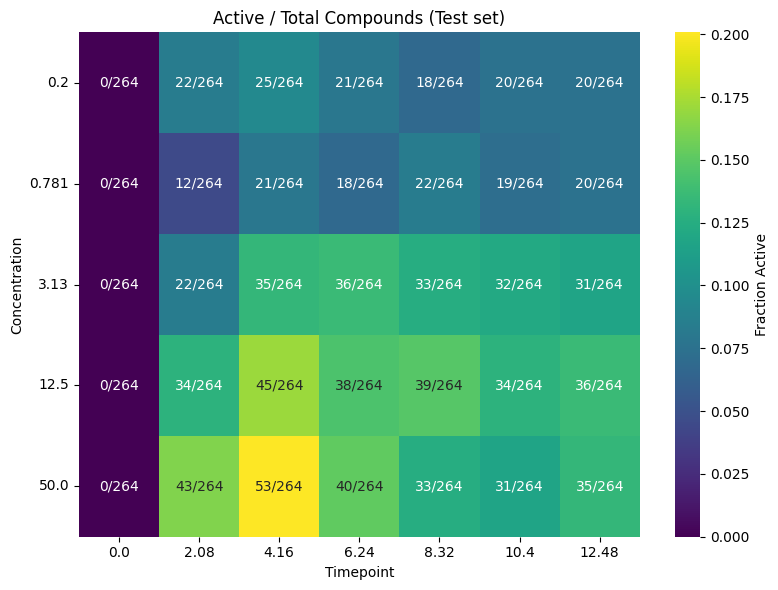

In [12]:
custom_bins = {
    -1: 20,
     0: 20,
     1: 20,
}

def correct_plate_batch_effect_DR(df: pd.DataFrame) -> pd.DataFrame:
    """
    Plate-level batch correction for DR dataset using inactive test compounds
    as the reference baseline (since no controls on the same plates).
    Preserves OD scale by dividing by plate median and multiplying by global median.
    """
    inactive = df[df['is_Active'] == 0]

    plate_medians = (
        inactive
        .groupby(['Plate_ID', 'Timepoint', 'Concentration'])['OD']
        .median()
        .reset_index(name='plate_med')
    )

    global_medians = (
        inactive
        .groupby(['Timepoint', 'Concentration'])['OD']
        .median()
        .reset_index(name='global_med')
    )

    df_norm = df.merge(plate_medians, on=['Plate_ID', 'Timepoint', 'Concentration'], how='left')
    df_norm = df_norm.merge(global_medians, on=['Timepoint', 'Concentration'], how='left')

    denom = df_norm['plate_med'].to_numpy()

    df_norm['OD'] = np.where(
        (denom > 0) & np.isfinite(denom),
        df_norm['OD'] / df_norm['plate_med'] * df_norm['global_med'],
        df_norm['OD']
    )

    df_norm.drop(columns=['plate_med', 'global_med'], inplace=True)
    return df_norm

df_Enamine_DR_growthCurves = label_inactives_actives(df_Enamine_DR_growthCurves, mad_multiplier=2)

df_Enamine_DR_plate_batch_effect_DR = correct_plate_batch_effect_DR(df_Enamine_DR_growthCurves)

df_Enamine_DR_plate_batch_effect_DR = label_inactives_actives(df_Enamine_DR_plate_batch_effect_DR, mad_multiplier=2)

plot_activity_ratio_heatmap(df_Enamine_DR_plate_batch_effect_DR)

# Iterative well correction: same convergence logic as t6_t12 branch.
# Uses k=2 seed labels (test-compound internal MAD) since DR has no on-plate DMSO.
# Final activity labels are set by the DMSO CV-rescaled threshold in the next cell.

df_Enamine_DR_plate_well_batch_effect_DR, dr_flip_history = iterate_label_and_well_correct(
    df_Enamine_DR_plate_batch_effect_DR,
    mad_multiplier=2,
    max_iters=10,
    tol=0.001,
    plot_each_iter=False,
)

df_Enamine_DR_plate_well_batch_effect_DR_avg = (
    df_Enamine_DR_plate_well_batch_effect_DR
      .drop(columns='Replicate')
      .groupby(
          ['Plate_ID', 'Concentration',
           'Compound', 'Control_Label', 'Timepoint'],
          as_index=False
      )
      .agg(
          OD        = ('OD', 'mean'),
          Smiles    = ('Smiles', 'first'),
          is_Active = ('is_Active', 'first'),
      )
)

print("Seed active fractions (k=2 internal-MAD, before DMSO CV rescaling):")
plot_activity_ratio_heatmap(df_Enamine_DR_plate_well_batch_effect_DR_avg)


## Redo labels using actual negative controls

iter 1: flips=705
iter 2: flips=4
Converged at iter 2.

Active counts (DMSO CV-rescaled threshold, k=4):


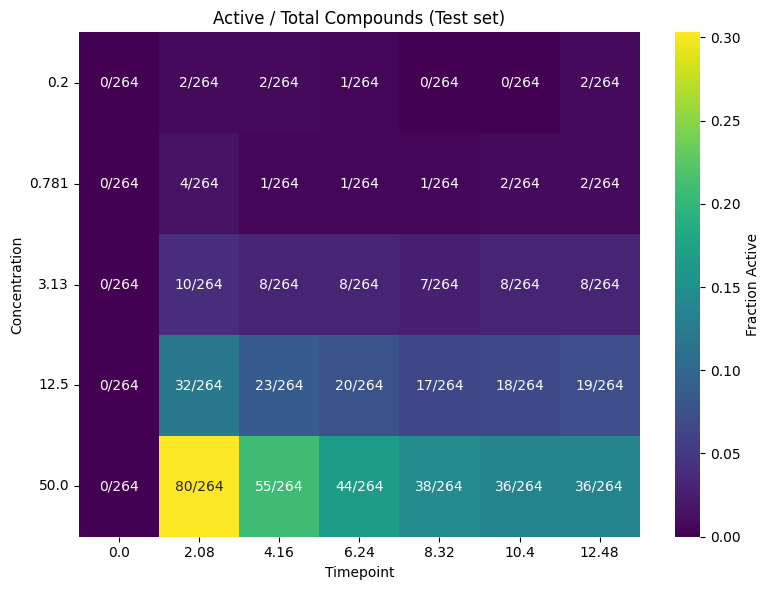


Active counts:
Timepoint      0.00   2.08   4.16   6.24   8.32   10.40  12.48
Concentration                                                 
0.200              0      2      2      1      0      0      2
0.781              0      4      1      1      1      2      2
3.130              0     10      8      8      7      8      8
12.500             0     32     23     20     17     18     19
50.000             0     80     55     44     38     36     36

Total counts:
Timepoint      0.00   2.08   4.16   6.24   8.32   10.40  12.48
Concentration                                                 
0.200            264    264    264    264    264    264    264
0.781            264    264    264    264    264    264    264
3.130            264    264    264    264    264    264    264
12.500           264    264    264    264    264    264    264
50.000           264    264    264    264    264    264    264

Active fraction (expect ~0.337 at 50µM/t=2.08, ~0.152 at 50µM/t=12.48):
Timepoint     

In [13]:
# Final activity labels via DMSO CV-rescaled iterative threshold (k=3).
# Formula: threshold(T, C) = m_DR_inactive(T, C) * (1 - k * CV_DMSO(T))
# DMSO CV is pooled across concentrations (concentration is a plate-layout artifact for DMSO;
# per-(T,C) CV is too noisy with few wells per cell). See dmso_threshold_methodology.md.

k = 4

dmso = df_cntrl[df_cntrl['Control_Label'] == -1]
cv_dmso = (
    dmso.groupby('Timepoint')['OD']
        .agg(
            median='median',
            mad=lambda x: 1.4826 * np.median(np.abs(x - x.median()))
        )
)
cv_dmso['cv'] = cv_dmso['mad'] / cv_dmso['median']


def iter_cv_label(df_avg, cv_dmso, k, max_iters=10, tol=0.001):
    """
    Iteratively relabel using the DMSO CV-rescaled multiplicative threshold.
    Resolves the circularity: m_DR_inactive depends on is_Active, which depends
    on the threshold, which depends on m_DR_inactive. Converges in ~3 rounds.
    """
    df_cur = df_avg.copy().reset_index(drop=True)
    for it in range(1, max_iters + 1):
        m_dr = (
            df_cur[df_cur['is_Active'] == 0]
              .groupby(['Timepoint', 'Concentration'])['OD']
              .median()
              .rename('m_dr_inactive')
              .reset_index()
        )
        thresh = m_dr.merge(cv_dmso[['cv']], left_on='Timepoint', right_index=True)
        thresh['threshold'] = thresh['m_dr_inactive'] * (1 - k * thresh['cv'])
        merged = (
            df_cur.drop(columns='threshold', errors='ignore')
                  .merge(thresh[['Timepoint', 'Concentration', 'threshold']],
                         on=['Timepoint', 'Concentration'], how='left')
                  .reset_index(drop=True)
        )
        new_active = ((merged['OD'] < merged['threshold']) & (merged['Timepoint'] > 0)).astype(int)
        flips = int((new_active.values != df_cur['is_Active'].values).sum())
        df_cur = merged.drop(columns='threshold')
        df_cur['is_Active'] = new_active.values
        print(f"iter {it}: flips={flips}")
        if flips / max(len(df_cur), 1) < tol:
            print(f"Converged at iter {it}.")
            break
    df_cur.loc[df_cur['Timepoint'] == 0, 'is_Active'] = 0
    return df_cur


df_dr_labeled = iter_cv_label(df_Enamine_DR_plate_well_batch_effect_DR_avg, cv_dmso, k=k)

print(f'\nActive counts (DMSO CV-rescaled threshold, k={k}):')
plot_activity_ratio_heatmap(df_dr_labeled)

_total = df_dr_labeled.groupby(['Concentration', 'Timepoint']).size().unstack()
_active = (
    df_dr_labeled[df_dr_labeled['is_Active'] == 1]
    .groupby(['Concentration', 'Timepoint']).size()
    .unstack()
    .reindex_like(_total).fillna(0).astype(int)
)
_frac = (_active / _total).round(3)

print("\nActive counts:")
print(_active.to_string())
print("\nTotal counts:")
print(_total.to_string())
print("\nActive fraction (expect ~0.337 at 50µM/t=2.08, ~0.152 at 50µM/t=12.48):")
print(_frac.to_string())


/home/ethan2/.GrowthCurve/.venv/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
/home/ethan2/.GrowthCurve/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/ethan2/.GrowthCurve/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


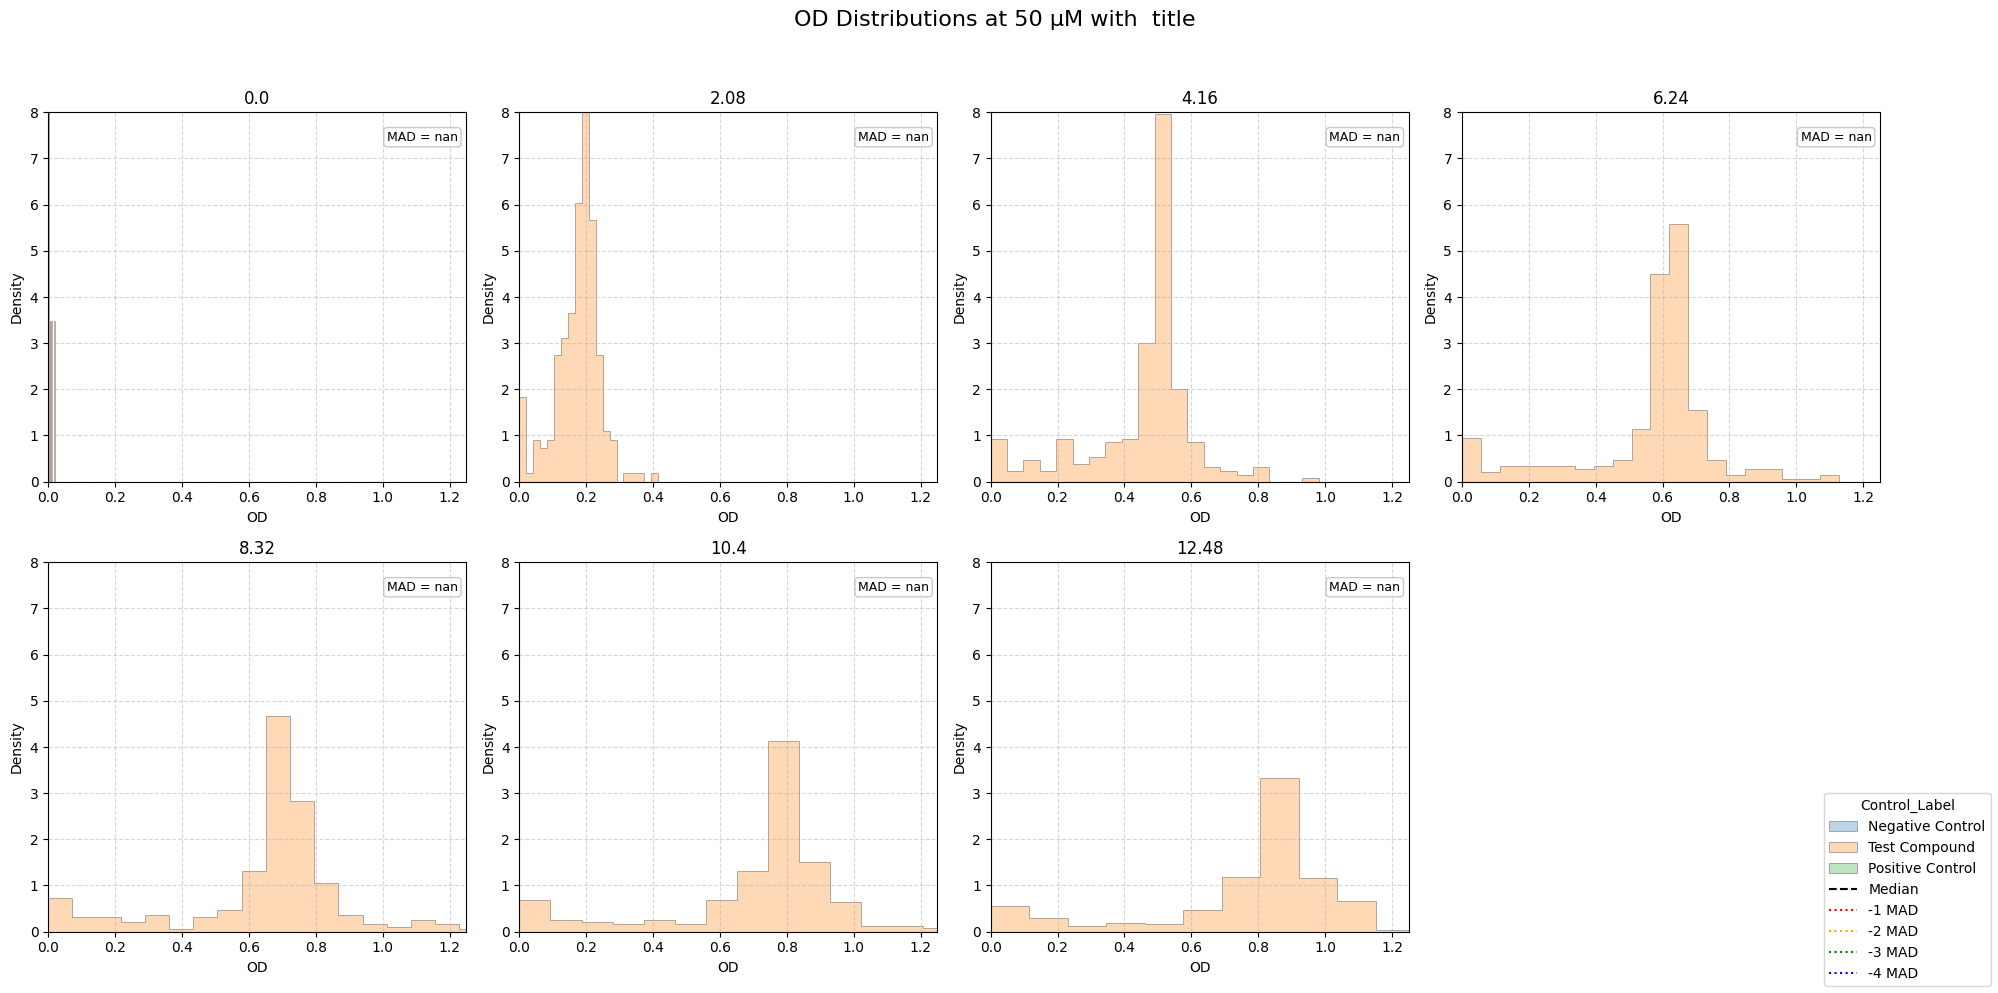

In [14]:
concentrations=[50]
for c in concentrations:
    plot_hist_od_distributions_long_neg_ctrl_threshold(
       ' title',
        correct_uncorrect='Plate + iterative well correction',
        dataset='df_Enamine_t6_t12',
        df_long=df_dr_labeled,
        concentration=c,
        bins=custom_bins, 
        max_x=1.25,
        max_density=8,
        save_path=False)

# Enamine t6 t12 processing

## Plate Correction

In [15]:
df_Enamine_plate_correction = correct_plate_batch_effect_dmso(df_Enamine.copy())

## Iterative well correction + labelling

Active-vs-inactive labels and the well-correction factor are interdependent: the
inactive subset defines the per-spot reference, but the threshold itself depends on
the corrected OD. The iterator alternates between (re)labelling and recomputing
well-correction factors on the *plate-corrected baseline* (factors are not
compounded across rounds), and stops when the fraction of label flips between
rounds drops below `tol`.

--- Initial labels (before any well correction) ---


/tmp/ipykernel_1026848/3253228211.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_compute_thresh)


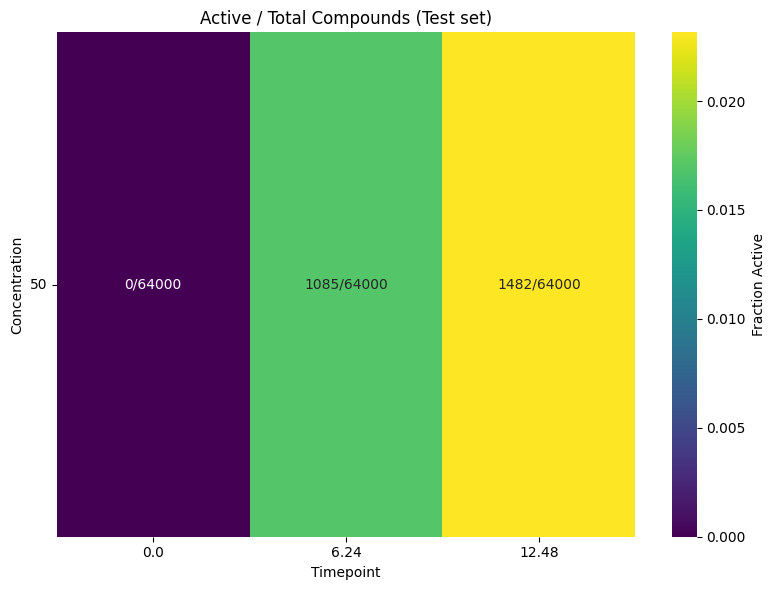

iter 1: flips=1192  (0.6208% of 192000 test rows)
--- Active labels after iter 1 ---


/tmp/ipykernel_1026848/3253228211.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_compute_thresh)


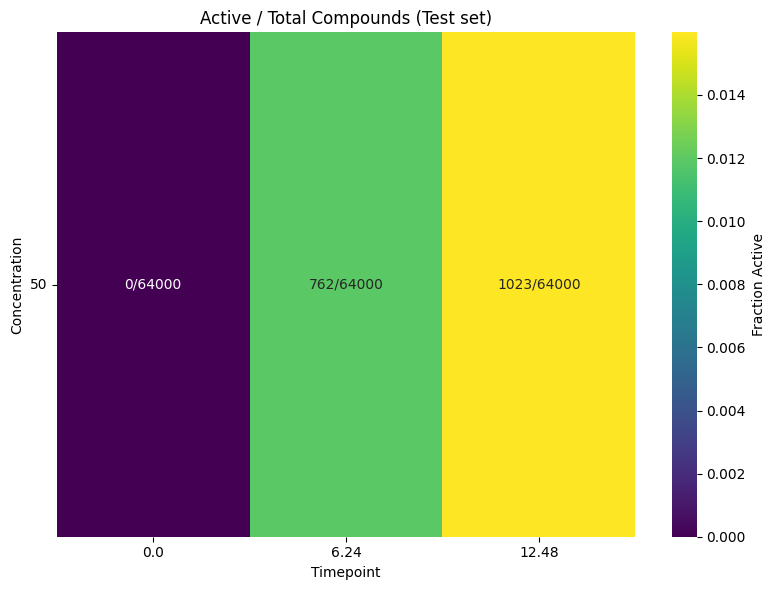

/tmp/ipykernel_1026848/3253228211.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_compute_thresh)


iter 2: flips=16  (0.0083% of 192000 test rows)
--- Active labels after iter 2 ---


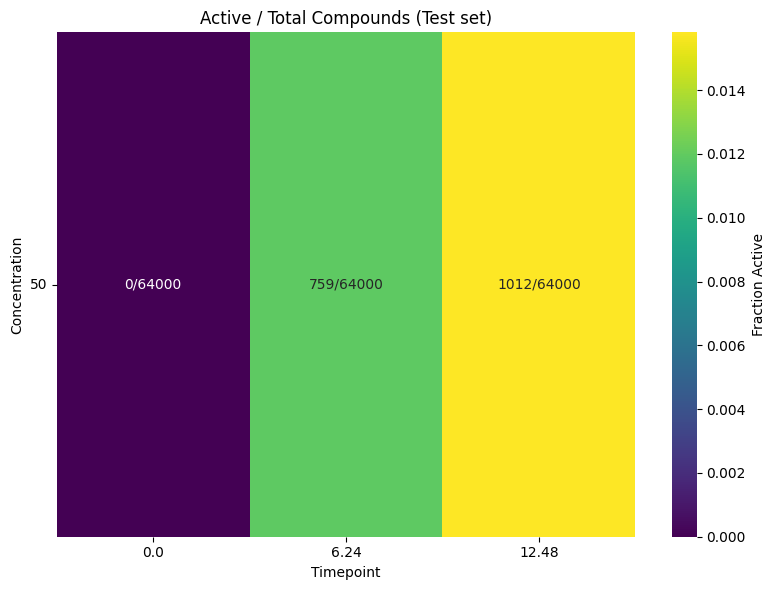

Converged at iter 2 (flip fraction < 0%).


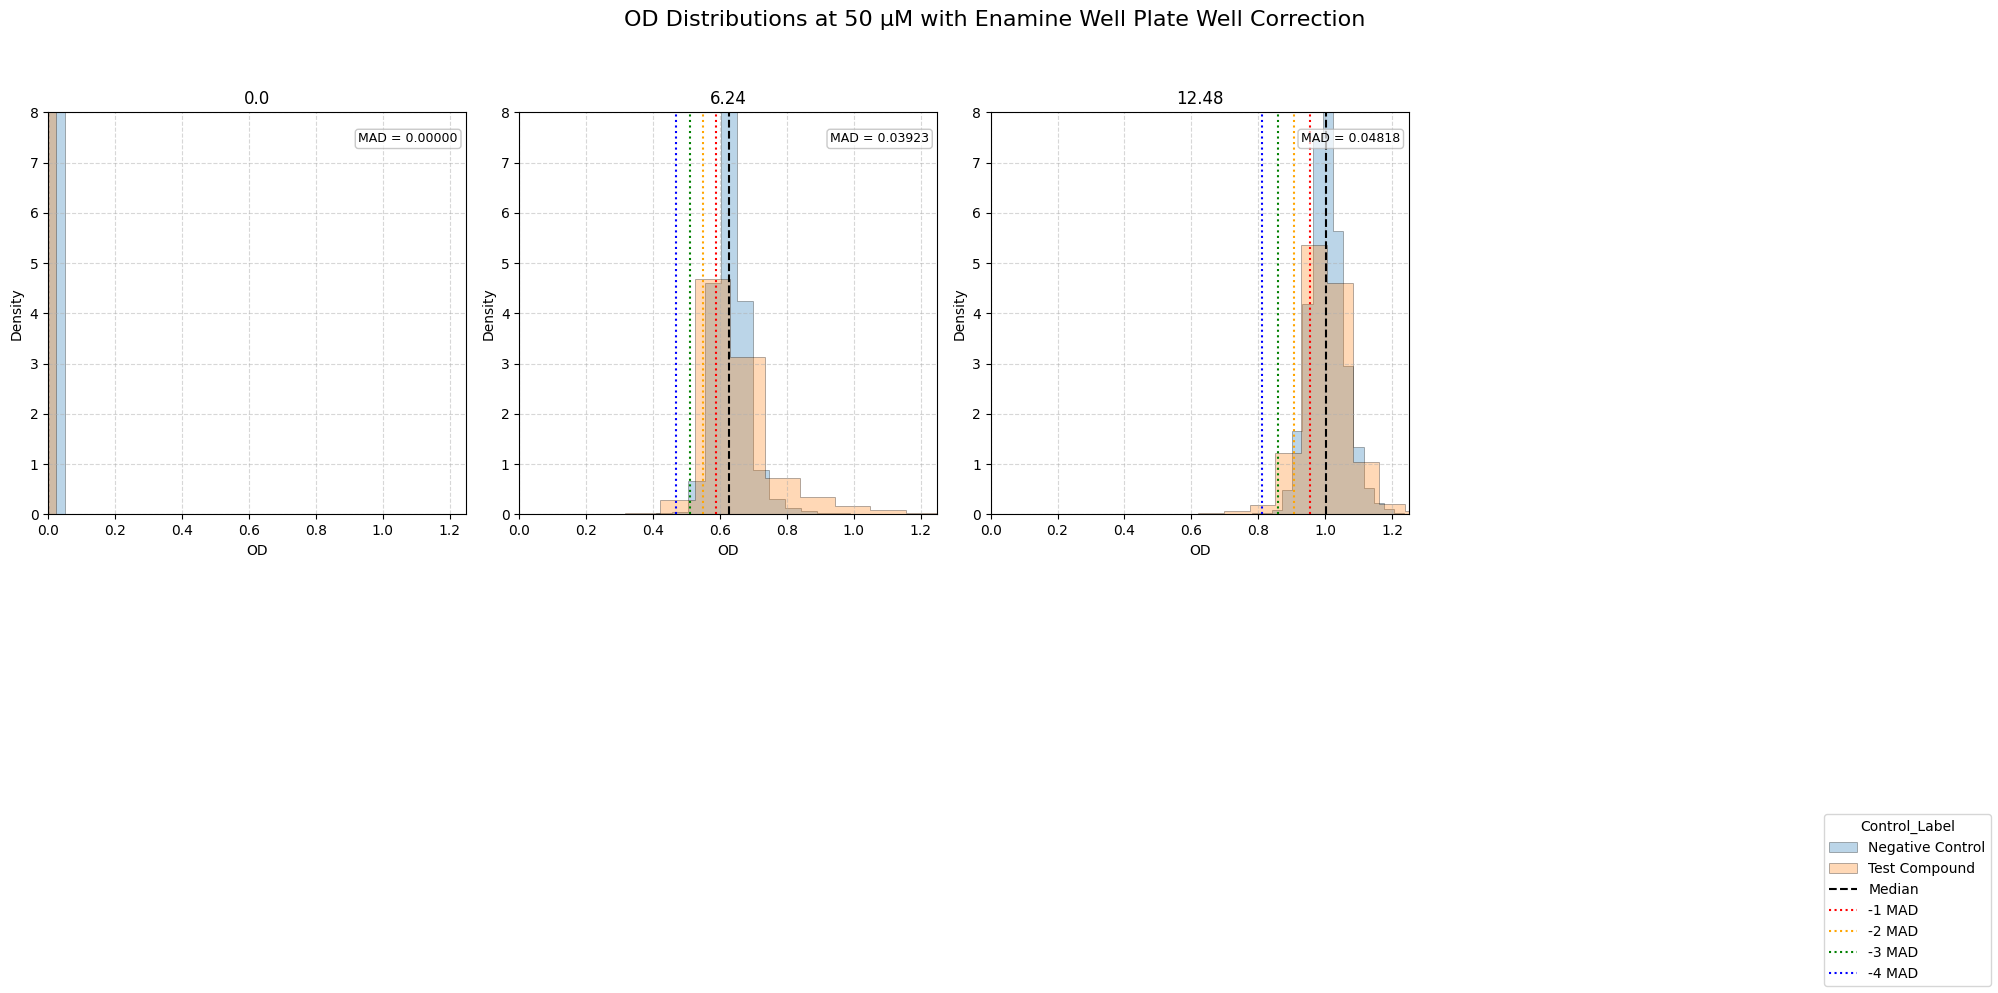

In [16]:
df_Enamine_plate_well_corrected, flip_history = iterate_label_and_well_correct(
    df_Enamine_plate_correction,
    mad_multiplier=4,
    max_iters=10,
    tol=0.001,
    plot_each_iter=True,
)

custom_bins = {
    -1: 20,                       # negatives
     0: 20,  # tests
     1: 20,                     # positives
}

title='Enamine Well Plate Well Correction'
concentrations=[50]
for c in concentrations:
    plot_hist_od_distributions_long_neg_ctrl_threshold(
        title,
        correct_uncorrect='correction_1',
        dataset='df_Enamine_t6_t12',
        df_long=df_Enamine_plate_well_corrected,
        concentration=c,
        bins=custom_bins, 
        max_x=1.25,
        max_density=8,
        plot_pos_ctrls=False,
        save_path=False
    )

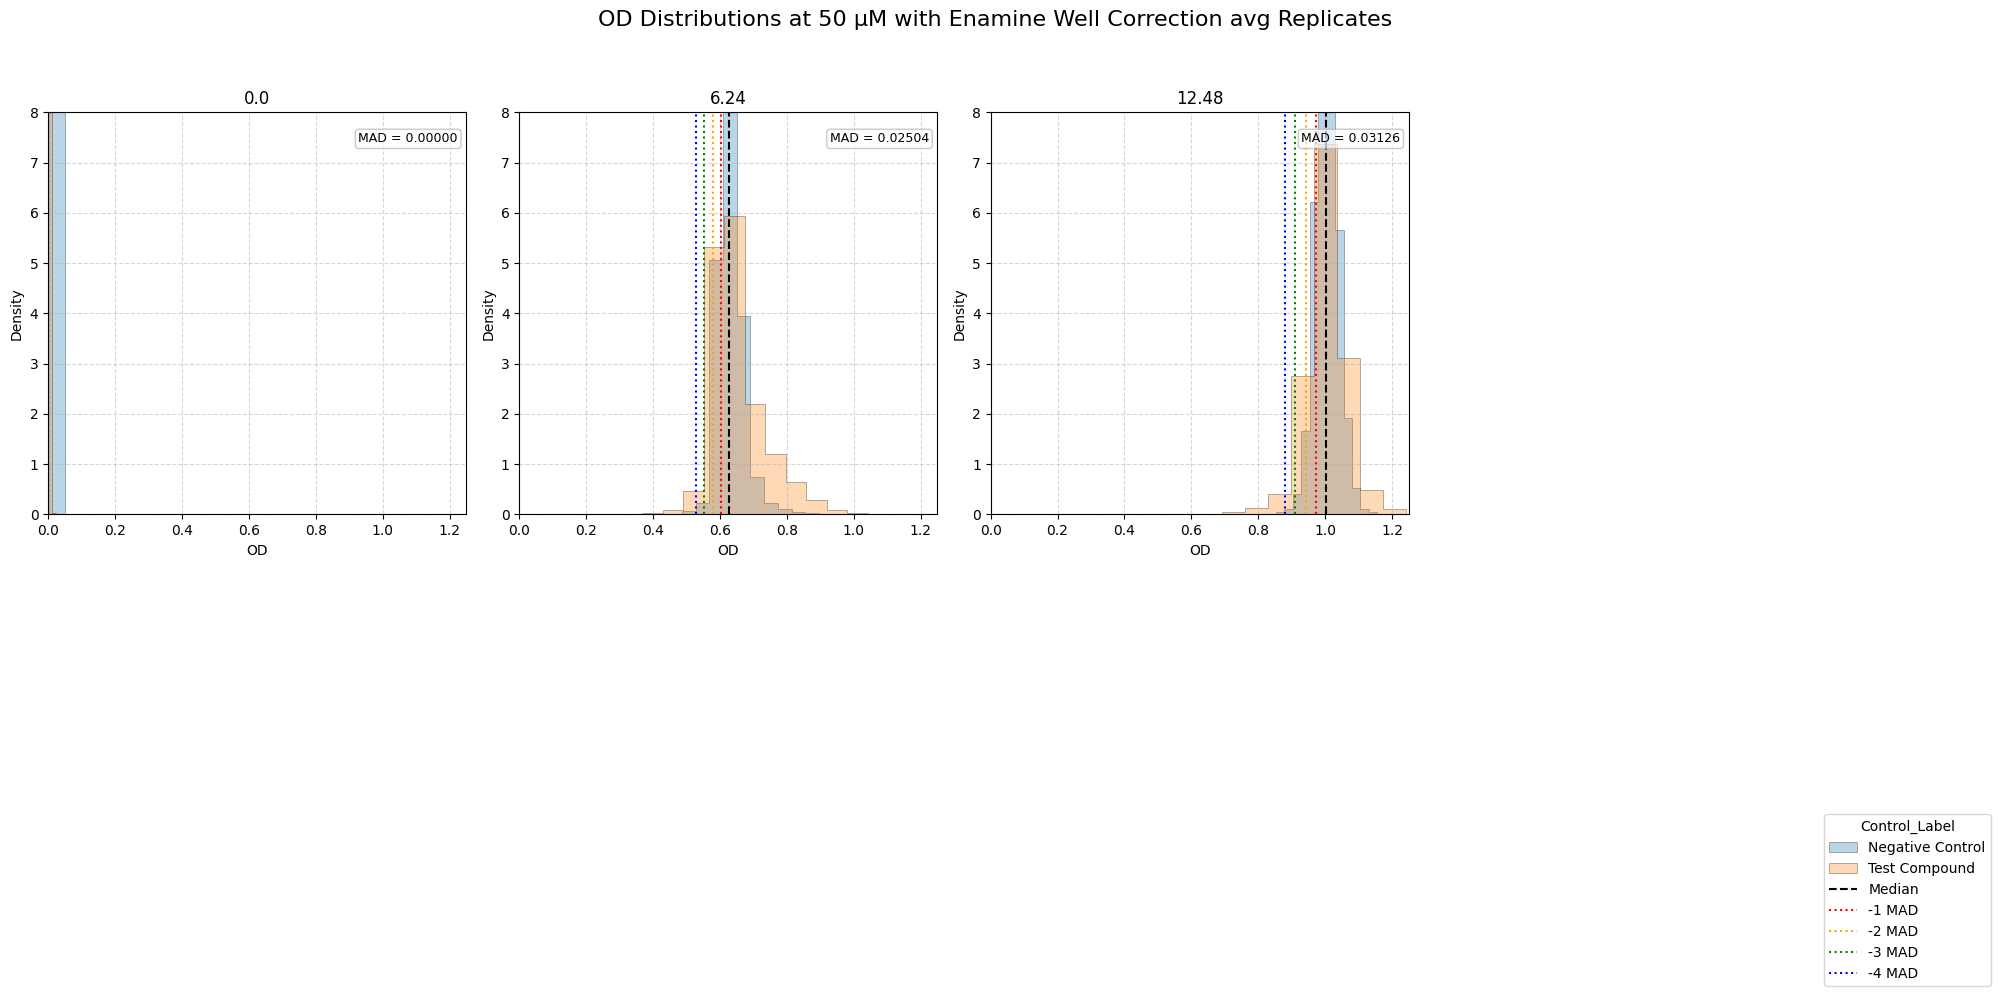

In [17]:
df_test_avg = (
      df_Enamine_plate_well_corrected[df_Enamine_plate_well_corrected['Control_Label'] == 0]                                          
        .groupby(['Plate_ID', 'Concentration', 'Compound',
  'Timepoint'], as_index=False)                                     
        .agg(     
            Control_Label = ('Control_Label', 'first'),
            OD            = ('OD', 'mean'),                         
            Smiles        = ('Smiles', 'first'),
        )                                                           
  ) 

# Controls: one row per (Plate, Well, Timepoint) — collapses replicates WITHIN a well
  # Keeping Well preserves the ~40 DMSO wells per plate so MAD is well-defined.  
  #                                                    
df_controls_avg = (
    df_Enamine_plate_well_corrected[df_Enamine_plate_well_corrected['Control_Label'] != 0]                                          
    .groupby(['Plate_ID', 'Well', 'Concentration', 'Compound',
'Timepoint'], as_index=False)                                     
    .agg(     
        Control_Label = ('Control_Label', 'first'),
        OD            = ('OD', 'mean'),                         
        Smiles        = ('Smiles', 'first'),
    )                                                           
)               

df_Enamine_plate_well_corrected_avg = pd.concat(                  
    [df_test_avg, df_controls_avg], ignore_index=True
) 


custom_bins = {
    -1: 20,                       # negatives
     0: 20,  # tests
     1: 20,                     # positives
}

title='Enamine Well Correction avg Replicates'
concentrations=[50]
for c in concentrations:
    plot_hist_od_distributions_long_neg_ctrl_threshold(
        title,
        correct_uncorrect='correction_1',
        dataset='df_Enamine_t6_t12',
        df_long=df_Enamine_plate_well_corrected_avg,
        concentration=c,
        bins=custom_bins, 
        max_x=1.25,
        max_density=8,
        plot_pos_ctrls=False,
        save_path=False
    )

/tmp/ipykernel_1026848/3253228211.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_compute_thresh)


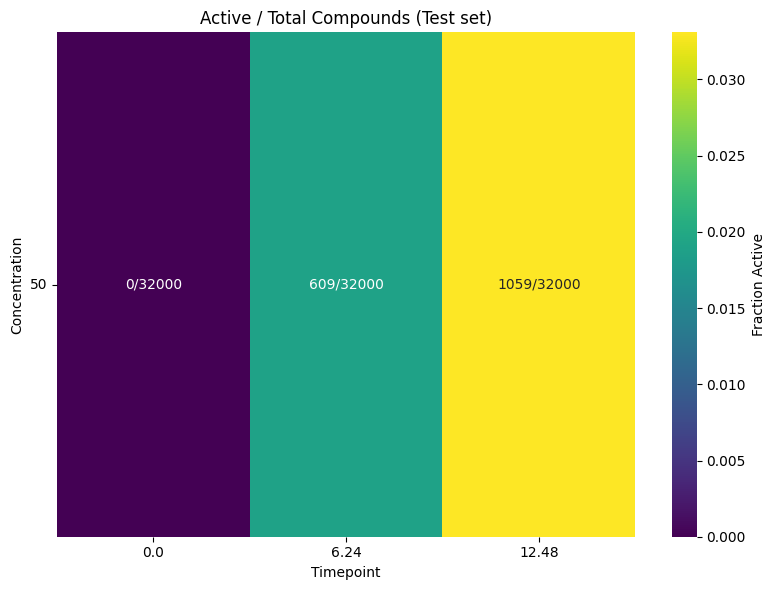

In [18]:
df_Enamine_plate_well_corrected_avg = label_inactives_actives(df_Enamine_plate_well_corrected_avg, mad_multiplier=4)
plot_activity_ratio_heatmap(df_Enamine_plate_well_corrected_avg[df_Enamine_plate_well_corrected_avg['Control_Label'] == 0])

In [19]:
# Verification checks

# 1. t6_t12: Ciprofloxacin recall at late timepoint (sensitivity check)
cipro_late = df_Enamine_plate_well_corrected_avg[
    (df_Enamine_plate_well_corrected_avg['Control_Label'] == 1) &
    (df_Enamine_plate_well_corrected_avg['Timepoint'] == 12.48)
]
cipro_evaluable = cipro_late[cipro_late['OD'].notna() & np.isfinite(cipro_late['OD'])]
print(f"Cipro rows @ t=12.48: {len(cipro_late)} total, {len(cipro_evaluable)} with finite OD")
print(f"  ({len(cipro_late) - len(cipro_evaluable)} NaN/inf — normalization artifact from extreme OD suppression)")
print(f"Cipro recall (finite OD only) @ t=12.48: {cipro_evaluable['is_Active'].mean():.2%} "
      f"({int(cipro_evaluable['is_Active'].sum())}/{len(cipro_evaluable)})")
print("Expected: >= 95%")

# 2. DR: active fractions vs. methodology doc § 7 table
print("\nDR active fractions (expect ~0.337 at 50µM/t=2.08, ~0.152 at 50µM/t=12.48):")
print(df_dr_labeled.groupby(['Concentration', 'Timepoint'])['is_Active']
                   .mean().round(3).unstack(0))

# 3. t6_t12: DMSO self-check — fraction of DMSO below own plate threshold should be ~0.1%
d = df_Enamine_plate_well_corrected_avg[df_Enamine_plate_well_corrected_avg['Timepoint'] == 12.48]
def _plate_thresh(g):
    dmso = g.loc[g['Control_Label'] == -1, 'OD']
    med = dmso.median()
    mad = 1.4826 * np.median(np.abs(dmso - med))
    return med - 4 * mad
plate_thresh = d.groupby(['Plate_ID', 'Concentration']).apply(_plate_thresh, include_groups=False).reset_index(name='thresh')
dm = d[d['Control_Label'] == -1].merge(plate_thresh, on=['Plate_ID', 'Concentration'])
print(f"\nDMSO below own plate threshold @ t=12.48: "
      f"{(dm['OD'] < dm['thresh']).sum()}/{len(dm)} "
      f"({(dm['OD'] < dm['thresh']).mean():.2%})")
print("Expected: ~0.1%")

# 4. Label rate comparison between experiments
t6_t12_active = (
    df_Enamine_plate_well_corrected_avg[
        (df_Enamine_plate_well_corrected_avg['Timepoint'] == 12.48) &
        (df_Enamine_plate_well_corrected_avg['Concentration'] == 50) &
        (df_Enamine_plate_well_corrected_avg['Control_Label'] == 0)
    ]['is_Active'].mean()
)
dr_active = (
    df_dr_labeled[
        (df_dr_labeled['Timepoint'] == 12.48) &
        (df_dr_labeled['Concentration'] == 50)
    ]['is_Active'].mean()
)
print(f"\nt6_t12 active rate @ t=12.48, 50µM: {t6_t12_active:.2%}")
print(f"DR active rate @ t=12.48, 50µM:    {dr_active:.2%}")
print("Note: DR is a re-assay of pre-selected hits; higher active rate is expected.")

Cipro rows @ t=12.48: 1600 total, 100 with finite OD
  (1500 NaN/inf — normalization artifact from extreme OD suppression)
Cipro recall (finite OD only) @ t=12.48: 100.00% (100/100)
Expected: >= 95%

DR active fractions (expect ~0.337 at 50µM/t=2.08, ~0.152 at 50µM/t=12.48):
Concentration  0.200   0.781   3.130   12.500  50.000
Timepoint                                            
0.00            0.000   0.000   0.000   0.000   0.000
2.08            0.008   0.015   0.038   0.121   0.303
4.16            0.008   0.004   0.030   0.087   0.208
6.24            0.004   0.004   0.030   0.076   0.167
8.32            0.000   0.004   0.027   0.064   0.144
10.40           0.000   0.008   0.030   0.068   0.136
12.48           0.008   0.008   0.030   0.072   0.136

DMSO below own plate threshold @ t=12.48: 5/4800 (0.10%)
Expected: ~0.1%

t6_t12 active rate @ t=12.48, 50µM: 3.31%
DR active rate @ t=12.48, 50µM:    13.64%
Note: DR is a re-assay of pre-selected hits; higher active rate is expected.


DR unique compounds:             264
Matched to t6_t12 by SMILES:     264


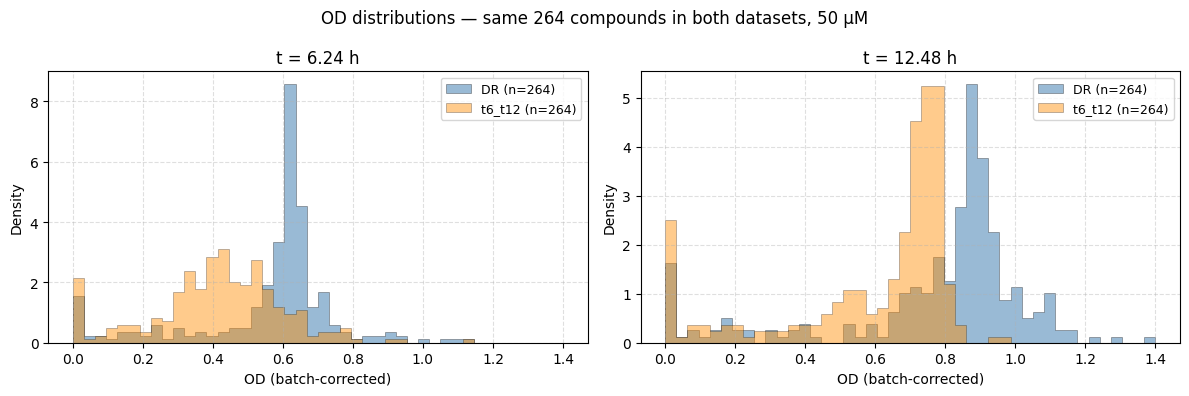


t= 6.24 h:  148/264 compounds disagree  | active in DR=44,  active in t6_t12=188
t=12.48 h:  223/264 compounds disagree  | active in DR=36,  active in t6_t12=259

Discordant compounds (371 rows):
 Timepoint Compound_DR    OD_DR  is_Active_DR  OD_t6t12  is_Active_t6t12
      6.24 Z1084007582 0.625172             0  0.493038                1
      6.24  Z115666676 0.619774             0  0.515360                1
      6.24  Z115677882 0.611998             0  0.412441                1
      6.24 Z1167894651 0.731704             0  0.316752                1
      6.24 Z1170088409 0.635408             0  0.358200                1
      6.24 Z1203873429 0.616840             0  0.359553                1
      6.24 Z1207296292 0.636642             0  0.305271                1
      6.24 Z1223049609 0.516836             0  0.292458                1
      6.24 Z1230093043 0.625144             0  0.366745                1
      6.24 Z1232341153 0.664909             0  0.303749                1


In [20]:
# ── Sanity check: DR ⊂ t6_t12 overlap ─────────────────────────────────────────
# DR is a re-assay of 264 compounds from t6_t12 at 50µM.
# Common timepoints: 6.24 h and 12.48 h.
# All filtering is to the intersection only — no extra t6_t12 compounds included.

TP_COMMON = [6.24, 12.48]
CONC = 50

dr_sub = df_dr_labeled[
    (df_dr_labeled['Control_Label'] == 0) &
    (df_dr_labeled['Concentration'] == CONC) &
    (df_dr_labeled['Timepoint'].isin(TP_COMMON))
][['Smiles', 'Compound', 'Timepoint', 'OD', 'is_Active']].copy()

t6_sub = df_Enamine_plate_well_corrected_avg[
    (df_Enamine_plate_well_corrected_avg['Control_Label'] == 0) &
    (df_Enamine_plate_well_corrected_avg['Concentration'] == CONC) &
    (df_Enamine_plate_well_corrected_avg['Timepoint'].isin(TP_COMMON))
][['Smiles', 'Compound', 'Timepoint', 'OD', 'is_Active']].copy()

# Restrict both datasets to the intersection of SMILES
common_smiles = set(dr_sub['Smiles'].unique()) & set(t6_sub['Smiles'].unique())
n_dr_total = dr_sub['Smiles'].nunique()
print(f"DR unique compounds:             {n_dr_total}")
print(f"Matched to t6_t12 by SMILES:     {len(common_smiles)}")
if len(common_smiles) < n_dr_total:
    unmatched = set(dr_sub['Smiles'].unique()) - common_smiles
    unmatched_names = dr_sub.loc[dr_sub['Smiles'].isin(unmatched), 'Compound'].unique()
    print(f"  WARNING: {len(unmatched)} DR SMILES not found in t6_t12:")
    print(f"  {list(unmatched_names)}")

dr_common = dr_sub[dr_sub['Smiles'].isin(common_smiles)]
t6_common = t6_sub[t6_sub['Smiles'].isin(common_smiles)]

# ── Plot: OD distributions (intersection only) ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bins = np.linspace(0, 1.4, 45)

for ax, tp in zip(axes, TP_COMMON):
    ax.hist(dr_common.loc[dr_common['Timepoint'] == tp, 'OD'].dropna(),
            bins=bins, alpha=0.55, density=True, color='steelblue',
            histtype='stepfilled', edgecolor='black', linewidth=0.4,
            label=f'DR (n={len(common_smiles)})')
    ax.hist(t6_common.loc[t6_common['Timepoint'] == tp, 'OD'].dropna(),
            bins=bins, alpha=0.45, density=True, color='darkorange',
            histtype='stepfilled', edgecolor='black', linewidth=0.4,
            label=f't6_t12 (n={len(common_smiles)})')
    ax.set_title(f't = {tp} h')
    ax.set_xlabel('OD (batch-corrected)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)

fig.suptitle(
    f'OD distributions — same {len(common_smiles)} compounds in both datasets, 50 µM',
    fontsize=12)
plt.tight_layout()
plt.show()

# ── Activity label disagreement ────────────────────────────────────────────────
merged = dr_common.merge(t6_common, on=['Smiles', 'Timepoint'],
                         suffixes=('_DR', '_t6t12'))

print()
for tp in TP_COMMON:
    sub = merged[merged['Timepoint'] == tp]
    disagree      = (sub['is_Active_DR'] != sub['is_Active_t6t12']).sum()
    active_dr     = int(sub['is_Active_DR'].sum())
    active_t6t12  = int(sub['is_Active_t6t12'].sum())
    print(f"t={tp:5.2f} h:  {disagree}/{len(sub)} compounds disagree  "
          f"| active in DR={active_dr},  active in t6_t12={active_t6t12}")

discordant = merged[merged['is_Active_DR'] != merged['is_Active_t6t12']].copy()
discordant = discordant.sort_values(['Timepoint', 'Compound_DR'])

if discordant.empty:
    print("\nAll matched compounds agree on activity label.")
else:
    print(f"\nDiscordant compounds ({len(discordant)} rows):")
    cols = ['Timepoint', 'Compound_DR', 'OD_DR', 'is_Active_DR', 'OD_t6t12', 'is_Active_t6t12']
    print(discordant[cols].to_string(index=False))

In [21]:
# ── Combine DR + t6_t12 into a single training dataframe ─────────────────────
# For the 264 compounds in both datasets, use DR data exclusively (DR is the
# dose-response re-assay — the confirmation measurement). For all other t6_t12
# compounds, keep their t6_t12 rows. Controls (DMSO, Cipro) from t6_t12 are
# retained regardless.

overlap_smiles = set(df_dr_labeled['Smiles']) & set(df_Enamine_plate_well_corrected_avg['Smiles'])
print(f"Overlap compounds (DR ∩ t6_t12): {len(overlap_smiles)}")

# Drop only TEST compounds (Control_Label == 0) that overlap; keep all controls
drop_mask = (
    (df_Enamine_plate_well_corrected_avg['Control_Label'] == 0) &
    (df_Enamine_plate_well_corrected_avg['Smiles'].isin(overlap_smiles))
)
df_t6_kept = df_Enamine_plate_well_corrected_avg[~drop_mask].copy()

df_combined = pd.concat([df_t6_kept, df_dr_labeled], ignore_index=True)

# ── Average positive controls (Cipro) to 1 row per (Smiles, Timepoint, Concentration) ──
# Cipro OD is NaN/inf in ~94% of rows (normalization artifact from extreme growth
# suppression); filter to finite OD before averaging.
cipro_mask = df_combined['Control_Label'] == 1
cipro_rows = df_combined[cipro_mask]
cipro_valid = cipro_rows[cipro_rows['OD'].notna() & np.isfinite(cipro_rows['OD'])]

cipro_avg = (
    cipro_valid
    .groupby(['Smiles', 'Compound', 'Timepoint', 'Concentration', 'Control_Label'],
             as_index=False)
    .agg(OD=('OD', 'mean'), is_Active=('is_Active', 'max'))
)

print(f"\nCipro rows: {int(cipro_mask.sum())} → {len(cipro_avg)} after averaging across wells/plates")
print(cipro_avg[['Timepoint', 'Concentration', 'OD', 'is_Active']].to_string(index=False))

df_combined = pd.concat([df_combined[~cipro_mask], cipro_avg], ignore_index=True)

# ── Sanity checks ─────────────────────────────────────────────────────────────
n_t6_test_orig = df_Enamine_plate_well_corrected_avg[
    df_Enamine_plate_well_corrected_avg['Control_Label'] == 0
]['Smiles'].nunique()
n_combined_test = df_combined[df_combined['Control_Label'] == 0]['Smiles'].nunique()
expected_test = (n_t6_test_orig - len(overlap_smiles)) + len(overlap_smiles)

print(f"\nTotal rows: {len(df_combined)}")
print(f"Unique test compounds: {n_combined_test}  (expected {expected_test})")

dup_test = df_combined[df_combined['Control_Label'] == 0].duplicated(
    ['Smiles', 'Timepoint', 'Concentration']).sum()
print(f"Duplicate (Smiles, Timepoint, Concentration) among test compounds: {dup_test}")

overlap_1248_50 = df_combined[
    (df_combined['Smiles'].isin(overlap_smiles)) &
    (df_combined['Timepoint'] == 12.48) &
    (df_combined['Concentration'] == 50)
]
nonoverlap_1248_50 = df_combined[
    (~df_combined['Smiles'].isin(overlap_smiles)) &
    (df_combined['Control_Label'] == 0) &
    (df_combined['Timepoint'] == 12.48) &
    (df_combined['Concentration'] == 50)
]
print(f"\nActive rate @ (12.48, 50):")
print(f"  Overlap compounds (DR-derived):        "
      f"{overlap_1248_50['is_Active'].mean():.2%} ({int(overlap_1248_50['is_Active'].sum())}/{len(overlap_1248_50)})")
print(f"  Non-overlap t6_t12 (t6_t12-derived):   "
      f"{nonoverlap_1248_50['is_Active'].mean():.2%} ({int(nonoverlap_1248_50['is_Active'].sum())}/{len(nonoverlap_1248_50)})")


Overlap compounds (DR ∩ t6_t12): 264

Cipro rows: 4800 → 3 after averaging across wells/plates
 Timepoint  Concentration       OD  is_Active
      0.00           50.0 0.007279          0
      6.24           50.0 0.429949          1
     12.48           50.0 0.005564          1

Total rows: 118851
Unique test compounds: 32000  (expected 32000)
Duplicate (Smiles, Timepoint, Concentration) among test compounds: 0

Active rate @ (12.48, 50):
  Overlap compounds (DR-derived):        13.64% (36/264)
  Non-overlap t6_t12 (t6_t12-derived):   2.52% (800/31736)


In [26]:
df_combined=df_combined[df_combined['Control_Label'] != -1]

In [28]:
# ── Save ──────────────────────────────────────────────────────────────────────
out_path = '/home/ethan2/GrowthNet/data/train/df_combined_Enamine.pkl'
df_combined.to_pickle(out_path)
print(f"\nSaved combined dataframe to: {out_path}")


Saved combined dataframe to: /home/ethan2/GrowthNet/data/train/df_combined_Enamine.pkl


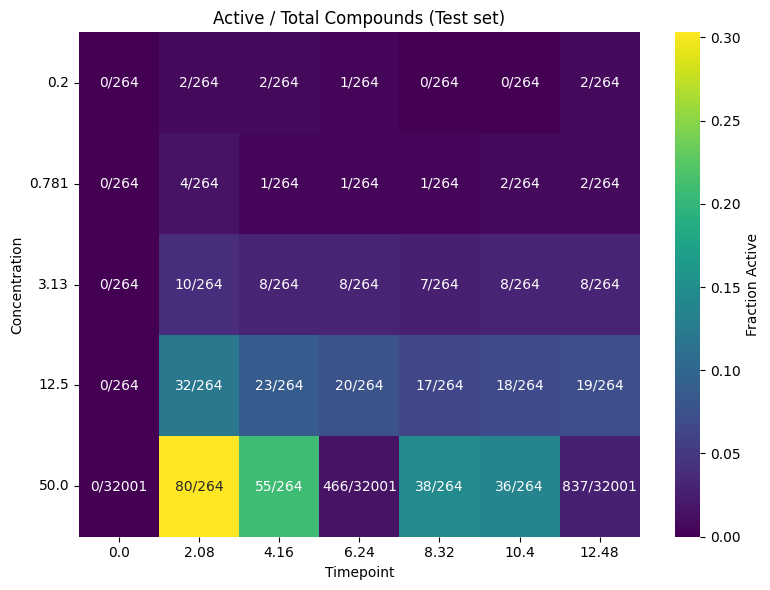

In [27]:
plot_activity_ratio_heatmap(df_combined)